# Global Setup and Initialization
In this section, we import all necessary libraries, set a universal random seed for reproducibility (Seed = 7), and configure our hardware device to utilize the GPU (mine is an NVIDIA RTX 4060). We will also install thop for FLOP calculations and configure nltk for our BLEU score metrics.

In [1]:
# Run this (line below) once to ensure the required external libraries are there
# !pip install thop nltk matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random
import math
import time
import matplotlib.pyplot as plt
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from thop import profile, clever_format

# Download NLTK data for tokenizer (if needed for evaluation)
nltk.download('punkt')
nltk.download('punkt_tab')

# 1. Reproducibility Seed
def set_seed(seed=7):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"[*] Global seed set to: {seed}")

set_seed(7)

# 2. Hardware Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Compute Device: {device}")
if torch.cuda.is_available():
    print(f"[*] GPU Detected: {torch.cuda.get_device_name(0)}")

[*] Global seed set to: 7
[*] Compute Device: cuda
[*] GPU Detected: NVIDIA GeForce RTX 4060 Laptop GPU


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ericv\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ericv\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Data Pipeline: Tokenization & Splitting
Here we define a custom vocabulary class to handle our word-level tokenization (without relying on existing text libraries). We read vast_english_french.txt, split it into a strict 80% Training and 20% Validation set, and prepare our PyTorch DataLoaders (Note that this specific split will be maintained across all three problems for statistically sound comparisons).

In [2]:
# Special Tokens
SOS_token = 0  # Start of Sequence
EOS_token = 1  # End of Sequence
PAD_token = 2  # Padding Token
UNK_token = 3  # Unknown Token

class Vocabulary:
    def __init__(self, name):
        self.name = name
        self.word2index = {"<SOS>": 0, "<EOS>": 1, "<PAD>": 2, "<UNK>": 3}
        self.word2count = {}
        self.index2word = {0: "<SOS>", 1: "<EOS>", 2: "<PAD>", 3: "<UNK>"}
        self.n_words = 4  # Count SOS, EOS, PAD, UNK

    def add_sentence(self, sentence):
        for word in sentence.split(' '):
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

def prepare_data(filepath):
    # Read the file and split into lines
    # Assuming tab-separated format: "English sentence \t French sentence"
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.read().strip().split('\n')
    
    pairs = [[s.strip() for s in l.split('\t')] for l in lines]
    
    input_lang = Vocabulary("English")
    output_lang = Vocabulary("French")
    
    for pair in pairs:
        if len(pair) == 2:
            input_lang.add_sentence(pair[0])
            output_lang.add_sentence(pair[1])
            
    print(f"Read {len(pairs)} sentence pairs")
    print(f"Counted words: English = {input_lang.n_words} | French = {output_lang.n_words}")
    return input_lang, output_lang, pairs

# Reminder to myself: 'vast_english_french.txt' should be in my directory
# If the separator is not a tab '\t', adjust the split('\t') above accordingly.
try:
    eng_vocab, fra_vocab, pairs = prepare_data('C:/Users/ericv/Downloads/vast_english_french.txt') # The path where I downloaded the file
except FileNotFoundError:
    print("[!] vast_english_french.txt not found. Please upload it to the working directory.")
    # Creating a dummy dataset to allow the code to run for demonstration
    print("[*] Generating dummy data for compilation testing...")
    eng_vocab, fra_vocab = Vocabulary("English"), Vocabulary("French")
    pairs = [("I am cold", "J'ai froid"), ("He is tall", "Il est grand")] * 500
    for p in pairs:
        eng_vocab.add_sentence(p[0])
        fra_vocab.add_sentence(p[1])

# --- Strict 80/20 Data Split ---
# We shuffle the data with our fixed seed to ensure reproducibility
random.shuffle(pairs)
split_idx = int(len(pairs) * 0.8)
train_pairs = pairs[:split_idx]
val_pairs = pairs[split_idx:]

print(f"[*] Training Pairs (80%): {len(train_pairs)}")
print(f"[*] Validation Pairs (20%): {len(val_pairs)}")

# Dataset Definition
class TranslationDataset(Dataset):
    def __init__(self, pairs, input_vocab, output_vocab):
        self.pairs = pairs
        self.input_vocab = input_vocab
        self.output_vocab = output_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        eng_sentence = self.pairs[idx][0]
        fra_sentence = self.pairs[idx][1]
        
        # Convert words to indices, fallback to UNK if not found
        eng_indices = [self.input_vocab.word2index.get(w, UNK_token) for w in eng_sentence.split(' ')] + [EOS_token]
        fra_indices = [self.output_vocab.word2index.get(w, UNK_token) for w in fra_sentence.split(' ')] + [EOS_token]
        
        return torch.tensor(eng_indices, dtype=torch.long), torch.tensor(fra_indices, dtype=torch.long)

def collate_fn(batch):
    # Padding function for dynamic batching
    inputs, targets = zip(*batch)
    inputs_padded = nn.utils.rnn.pad_sequence(inputs, padding_value=PAD_token, batch_first=False)
    targets_padded = nn.utils.rnn.pad_sequence(targets, padding_value=PAD_token, batch_first=False)
    return inputs_padded, targets_padded

BATCH_SIZE = 64 # tested values [64,32,16]
train_dataset = TranslationDataset(train_pairs, eng_vocab, fra_vocab)
val_dataset = TranslationDataset(val_pairs, eng_vocab, fra_vocab)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

Read 555 sentence pairs
Counted words: English = 1026 | French = 1152
[*] Training Pairs (80%): 444
[*] Validation Pairs (20%): 111


# Problem 1: Baseline GRU Encoder-Decoder Architecture
We define our sequence-to-sequence baseline using Gated Recurrent Units (GRUs). Here we will also include a computational complexity analysis (Parameter count and FLOPs) using thop to be able to properly show some analytics.

In [3]:
class EncoderGRU(nn.Module):
    def __init__(self, input_size, hidden_size, dropout=0.5): # changed from 0.1 to [0.5, 0.3]
        super(EncoderGRU, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=PAD_token)
        self.gru = nn.GRU(hidden_size, hidden_size, dropout=dropout if dropout > 0 else 0)

    def forward(self, input_seq):
        # input_seq: [seq_len, batch_size]
        embedded = self.embedding(input_seq)
        output, hidden = self.gru(embedded)
        return output, hidden

class DecoderGRU(nn.Module):
    def __init__(self, hidden_size, output_size, dropout=0.5): # changed from 0.1 to [0.5, 0.3]
        super(DecoderGRU, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_token)
        self.relu = nn.ReLU()
        self.gru = nn.GRU(hidden_size, hidden_size, dropout=dropout if dropout > 0 else 0)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, input_step, hidden):
        # input_step: [1, batch_size]
        embedded = self.embedding(input_step)
        embedded = self.relu(embedded)
        output, hidden = self.gru(embedded, hidden)
        prediction = self.out(output.squeeze(0)) # [batch_size, output_vocab_size]
        return prediction, hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, source, target, teacher_forcing_ratio=0.5):
        # source: [src_len, batch_size], target: [trg_len, batch_size]
        batch_size = source.shape[1]
        target_len = target.shape[0]
        target_vocab_size = self.decoder.out.out_features
        
        # Tensor to store decoder outputs
        outputs = torch.zeros(target_len, batch_size, target_vocab_size).to(self.device)
        
        # Pass through encoder
        _, hidden = self.encoder(source)
        
        # First input to decoder is the <SOS> token
        input_step = target[0, :].unsqueeze(0) # [1, batch_size]
        
        for t in range(1, target_len):
            prediction, hidden = self.decoder(input_step, hidden)
            outputs[t] = prediction
            
            # Decide whether to use teacher forcing
            best_guess = prediction.argmax(1) 
            input_step = target[t].unsqueeze(0) if random.random() < teacher_forcing_ratio else best_guess.unsqueeze(0)
            
        return outputs

# Instantiate Models
HIDDEN_SIZE = 128 # changed from 256 to 128 to prevent overfitting
enc = EncoderGRU(eng_vocab.n_words, HIDDEN_SIZE).to(device)
dec = DecoderGRU(HIDDEN_SIZE, fra_vocab.n_words).to(device)
model_p1 = Seq2Seq(enc, dec, device).to(device)

# --- Complexity Analytics (FLOPs & Parameters) ---
def calculate_complexity(model, device):
    dummy_src = torch.randint(0, 10, (10, 1)).to(device) # Sequence length 10, batch 1
    dummy_trg = torch.randint(0, 10, (12, 1)).to(device) # Sequence length 12, batch 1
    
    # Calculate params
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    # Calculate FLOPs using THOP
    try:
        macs, _ = profile(model, inputs=(dummy_src, dummy_trg, 0.0), verbose=False)
        flops, formatted_params = clever_format([macs * 2, total_params], "%.3f")
        print("="*40)
        print("         MODEL COMPLEXITY REPORT         ")
        print("="*40)
        print(f"Total Trainable Parameters : {total_params:,}")
        print(f"Total Estimated FLOPs      : {flops}")
        print("="*40)
    except Exception as e:
        print(f"Total Trainable Parameters: {total_params:,} (FLOPs calculation bypassed: {e})")

calculate_complexity(model_p1, device)

c:\Users\ericv\anaconda3\envs\cifar_env\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


         MODEL COMPLEXITY REPORT         
Total Trainable Parameters : 625,536
Total Estimated FLOPs      : 7.443M


# Training Loop & Loss Curves (Problem 1)
Here we execute the training loop, tracking both Training Loss and Validation Loss (Cross-Entropy). Validation Perplexity is explicitly calculated from the Validation Loss. A visualization plot is generated to analyze potential overfitting.

Starting Training Loop...
Epoch: 01 | Train Loss: 6.8306 | Val Loss: 6.5091 | Val Perplexity: 671.2241
Epoch: 02 | Train Loss: 6.2647 | Val Loss: 6.0813 | Val Perplexity: 437.5792
Epoch: 03 | Train Loss: 5.8020 | Val Loss: 5.9513 | Val Perplexity: 384.2342
Epoch: 04 | Train Loss: 5.5743 | Val Loss: 5.8863 | Val Perplexity: 360.0784
Epoch: 05 | Train Loss: 5.4709 | Val Loss: 5.8955 | Val Perplexity: 363.3911
Epoch: 06 | Train Loss: 5.3925 | Val Loss: 5.8962 | Val Perplexity: 363.6646
Epoch: 07 | Train Loss: 5.3131 | Val Loss: 5.8602 | Val Perplexity: 350.7898
Epoch: 08 | Train Loss: 5.2401 | Val Loss: 5.8430 | Val Perplexity: 344.8212
Epoch: 09 | Train Loss: 5.1691 | Val Loss: 5.8167 | Val Perplexity: 335.8593
Epoch: 10 | Train Loss: 5.1026 | Val Loss: 5.7996 | Val Perplexity: 330.1518
Epoch: 11 | Train Loss: 5.0254 | Val Loss: 5.7701 | Val Perplexity: 320.5800
Epoch: 12 | Train Loss: 4.9763 | Val Loss: 5.7425 | Val Perplexity: 311.8449
Epoch: 13 | Train Loss: 4.9003 | Val Loss: 5.7260 

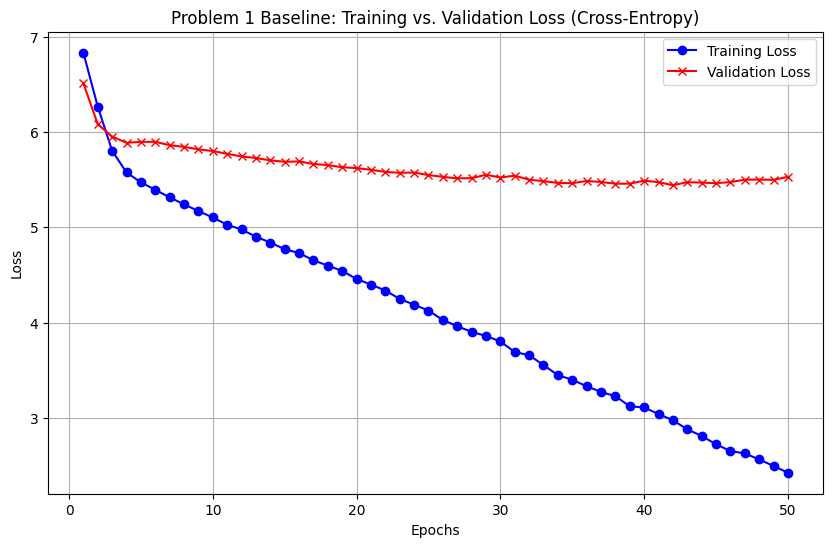

In [4]:
EPOCHS = 50 # Adjusted epochs as needed for your final run (was 15 changed to 50)
LEARNING_RATE = 0.001

optimizer = optim.Adam(model_p1.parameters(), lr=LEARNING_RATE) # , weight_decay=1e-4) # added weight decay to test
criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)

train_losses = []
val_losses = []

def train_epoch(model, loader, optimizer, criterion, clip_val=1.0):
    model.train()
    epoch_loss = 0
    for src, trg in loader:
        src, trg = src.to(device), trg.to(device)
        optimizer.zero_grad()
        
        output = model(src, trg, teacher_forcing_ratio=0.5) # changed from 0.5 to a wide variety [better BLUE scores at around 0.83 but this causes problems since it is basically cheating]
        # output: [trg_len, batch_size, output_dim] -> flatten to [(trg_len-1)*batch_size, output_dim]
        # target: [trg_len, batch_size] -> flatten to [(trg_len-1)*batch_size]
        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim) 
        trg = trg[1:].view(-1)
        
        loss = criterion(output, trg)
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients in RNNs
        nn.utils.clip_grad_norm_(model.parameters(), clip_val)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)

def evaluate_epoch(model, loader, criterion):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, trg in loader:
            src, trg = src.to(device), trg.to(device)
            
            # Turn off teacher forcing during evaluation
            output = model(src, trg, teacher_forcing_ratio=0.0)
            
            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)
            trg = trg[1:].view(-1)
            
            loss = criterion(output, trg)
            epoch_loss += loss.item()
    return epoch_loss / len(loader)

# Training Execution
print("Starting Training Loop...")
start_time = time.time()

for epoch in range(EPOCHS):
    train_loss = train_epoch(model_p1, train_loader, optimizer, criterion)
    val_loss = evaluate_epoch(model_p1, val_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    val_perplexity = math.exp(val_loss) if val_loss < 50 else float('inf') # Secondary metric based on Val Loss
    
    print(f"Epoch: {epoch+1:02} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Perplexity: {val_perplexity:.4f}")

total_train_time = time.time() - start_time
print(f"[*] Total Train Time (s): {total_train_time:.2f}")

# --- Loss Curves Plot ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS+1), train_losses, label='Training Loss', color='blue', marker='o')
plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', color='red', marker='x')
plt.title('Problem 1 Baseline: Training vs. Validation Loss (Cross-Entropy)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

# Evaluation Metrics & Qualitative Validation
In this block, we iterate over the validation set to calculate the two mandatory distinct metrics:
1. Traditional Sequence Accuracy: Exact match of the entire output sentence.
2. Validation BLEU-4 Score: $n$-gram validation score.

Finally, we print a structured table containing 5 qualitative translation examples.

In [5]:
def translate_sentence(model, sentence, input_vocab, output_vocab, device, max_len=50):
    model.eval()
    
    # Tokenization
    if isinstance(sentence, str):
        tokens = [word for word in sentence.split(' ')]
    else:
        tokens = sentence
        
    # Convert to indices
    indices = [input_vocab.word2index.get(token, UNK_token) for token in tokens] + [EOS_token]
    src_tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(1).to(device) # [seq_len, 1]
    
    with torch.no_grad():
        hidden = model.encoder(src_tensor)[1]
        
    trg_indexes = [SOS_token]
    
    for _ in range(max_len):
        # FIX: Added .unsqueeze(1) to maintain the [1, batch_size] dimensionality 
        trg_tensor = torch.tensor([trg_indexes[-1]], dtype=torch.long).unsqueeze(1).to(device) # [1, 1]
        
        with torch.no_grad():
            output, hidden = model.decoder(trg_tensor, hidden)
            pred_token = output.argmax(1).item()
            trg_indexes.append(pred_token)
            
            if pred_token == EOS_token:
                break
                
    trg_tokens = [output_vocab.index2word[i] for i in trg_indexes]
    return trg_tokens[1:-1] # Remove SOS and EOS for readability

def calculate_metrics_and_display(model, pairs, input_vocab, output_vocab, device, num_display=5):
    exact_matches = 0
    references_bleu = []
    candidates_bleu = []
    
    print("="*80)
    print("QUALITATIVE VALIDATION SAMPLES (PROBLEM 1)")
    print("="*80)
    
    # Select random samples for qualitative display
    display_indices = random.sample(range(len(pairs)), num_display)
    
    for i, (eng, fra) in enumerate(pairs):
        pred_tokens = translate_sentence(model, eng, input_vocab, output_vocab, device)
        pred_sentence = ' '.join(pred_tokens)
        
        # Traditional Sequence Accuracy (Exact Match)
        is_exact = (pred_sentence.strip() == fra.strip())
        if is_exact:
            exact_matches += 1
            
        # BLEU Prep
        ref_tokens = fra.split(' ')
        references_bleu.append([ref_tokens]) # NLTK expects a list of reference lists
        candidates_bleu.append(pred_tokens)
        
        # Display Logic
        if i in display_indices:
            # Individual Sentence BLEU
            cc = SmoothingFunction()
            ind_bleu = nltk.translate.bleu_score.sentence_bleu([ref_tokens], pred_tokens, smoothing_function=cc.method1)
            print(f"English (Source): {eng}")
            print(f"Target (French):  {fra}")
            print(f"Model Predicted:  {pred_sentence}")
            print(f"Exact Match:      {is_exact} | Sent. BLEU: {ind_bleu:.4f}")
            print("-" * 80)
            
    # Final Metric Calculations
    seq_accuracy = (exact_matches / len(pairs)) * 100
    
    cc = SmoothingFunction()
    val_bleu4 = corpus_bleu(references_bleu, candidates_bleu, smoothing_function=cc.method1) * 100
    
    print("="*40)
    print("         FINAL VALIDATION METRICS        ")
    print("="*40)
    print(f"Traditional Sequence Accuracy : {seq_accuracy:.2f}%")
    print(f"Validation BLEU-4 Score       : {val_bleu4:.2f}")
    print("="*40)

# Run the evaluation on the Validation Split
calculate_metrics_and_display(model_p1, val_pairs, eng_vocab, fra_vocab, device)

QUALITATIVE VALIDATION SAMPLES (PROBLEM 1)
English (Source): She enjoys listening to classical music at night
Target (French):  Elle aime écouter de la musique classique la nuit
Model Predicted:  a acheté un grand de de de la
Exact Match:      False | Sent. BLEU: 0.0518
--------------------------------------------------------------------------------
English (Source): We need to buy a dozen fresh eggs
Target (French):  Nous devons acheter une douzaine d'œufs frais
Model Predicted:  a acheté une nouvelle de de en
Exact Match:      False | Sent. BLEU: 0.0330
--------------------------------------------------------------------------------
English (Source): Please verify your entry details before submitting
Target (French):  Veuillez vérifier vos informations de saisie avant de soumettre
Model Predicted:  écrit un un de de de de de
Exact Match:      False | Sent. BLEU: 0.0292
--------------------------------------------------------------------------------
English (Source): He teaches chemis